### Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from scipy import stats

### Data Preprocessing

In [2]:
# Load datasets
df1 = pd.read_csv('Data_2004_2013.csv')

# Set the timestamp column as the index
df1['TimeStamp_1'] = pd.to_datetime(df1['TimeStamp_1'], format='mixed')
df1.set_index('TimeStamp_1', inplace=True)

# Train-Test split
# df_train: [2004-11-01 00:00:00 ~ 2007-10-31 23:00:00, 2008-11-01 00:00:00 ~ 2013-10-31 23:00:00]
# df_test: [2007-11-01 00:00:00 ~ 2008-10-31 23:00:00]
split1 = pd.to_datetime('2007-10-31 23:59:00')
split2 = pd.to_datetime('2008-10-31 23:59:00')
split3 = pd.to_datetime('2009-10-31 23:59:00')
df_train = df1[(df1.index < split1) | (df1.index > split2)]
df_test = df1[(df1.index > split1) & (df1.index < split2)]
df_val = df1[(df1.index > split2) & (df1.index < split3)]

# Data normalization
scaled_wave = MinMaxScaler()
scaled_wave = scaled_wave.fit(df_train[['H']])

### Model Evaluation

In [3]:
# Adjust the shape of Sigmoid function
def adjusted_probs(p, shift):
    p = np.clip(p, 1e-10, 1 - 1e-10)
    logit = np.log(p / (1 - p))
    return 1 / (1 + np.exp(-(logit - shift)))

# Search the best shift parameter
def search_shifts(df):
    best_shift, lowest_rmse = None, float('inf')
    for shift in np.arange(-5, 5.01, 0.01):
        probs = adjusted_probs(df['Spike_prob'], shift)
        y_pred = (1 - probs) * df['H_pred0'] + probs * df['H_pred1']
        y_pred_raw = scaled_wave.inverse_transform(y_pred.values.reshape(-1, 1))
        rmse = np.sqrt(mean_squared_error(df['H'], y_pred_raw))
        if rmse < lowest_rmse:
            best_shift, lowest_rmse = shift, rmse
    return best_shift

# Best shifts in the windy season
df = df_val[(df_val.index.month <= 3) | (df_val.index.month >= 11)]
best_shifts = [search_shifts(df)] * 12

# Best shifts in the calm season
for i in range(3, 10):
    df = df_val[df_val.index.month == i+1]
    best_shifts[i] = search_shifts(df)

print("Best shifts:", ", ".join(f"{x:.3f}" for x in best_shifts))

Best shifts: 4.130, 4.130, 4.130, 5.000, 5.000, 5.000, 2.350, 4.500, -2.680, -2.540, 4.130, 4.130


In [4]:
for i in range(12):
    month_mask = (df_test.index.month == i+1)
    df_test.loc[month_mask, 'Spike_prob'] = adjusted_probs(df_test.loc[month_mask, 'Spike_prob'], best_shifts[i])

# Test RMSE
y_pred3 = (1 - df_test['Spike_prob']) * df_test['H_pred0'] + df_test['Spike_prob'] * df_test['H_pred1']
y_pred3_raw = scaled_wave.inverse_transform(y_pred3.values.reshape(-1, 1))
y_true3 = df_test['H']
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_true3, y_pred3_raw)):.3f}')

# Windy season RMSE
df_test1 = df_test[(df_test.index.month >= 11) | (df_test.index.month <= 3)]
y_pred1 = (1 - df_test1['Spike_prob']) * df_test1['H_pred0'] + df_test1['Spike_prob'] * df_test1['H_pred1']
y_pred1_raw = scaled_wave.inverse_transform(y_pred1.values.reshape(-1, 1))
print(f'Windy Season RMSE: {np.sqrt(mean_squared_error(df_test1['H'], y_pred1_raw)):.3f}')

# Calm season RMSE
df_test2 = df_test[(df_test.index.month >= 4) & (df_test.index.month <= 10)]
y_pred2 = (1 - df_test2['Spike_prob']) * df_test2['H_pred0'] + df_test2['Spike_prob'] * df_test2['H_pred1']
y_pred2_raw = scaled_wave.inverse_transform(y_pred2.values.reshape(-1, 1))
print(f'Calm Season RMSE: {np.sqrt(mean_squared_error(df_test2['H'], y_pred2_raw)):.3f}')

Test RMSE: 0.711
Windy Season RMSE: 0.800
Calm Season RMSE: 0.640


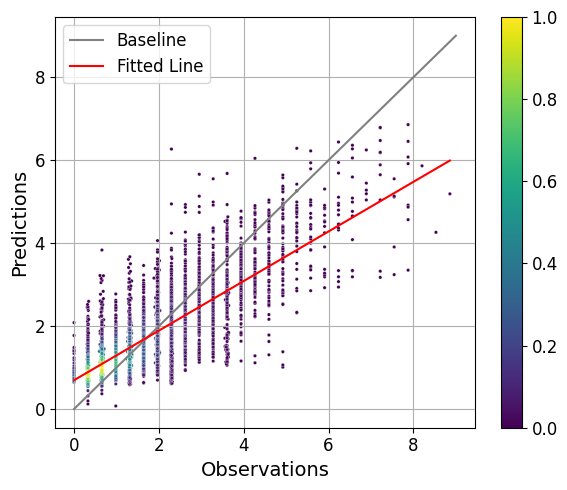

In [5]:
def pred_vs_obs(y_true, y_pred):
    y_pred = y_pred.flatten()
    fig, ax = plt.subplots(figsize=(6, 5))
    
    ax.plot([0, 9], [0, 9], color='grey', label='Baseline')
    ax.plot(np.unique(y_true), np.poly1d(np.polyfit(y_true,y_pred,1))(np.unique(y_true)), color='r', label='Fitted Line')
    ax.set_xlabel('Observations', fontsize=14)
    ax.set_ylabel('Predictions', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid()
    
    kernel = stats.gaussian_kde(np.vstack([y_true, y_pred]))(np.vstack([y_true, y_pred]))
    sns.scatterplot(x=y_true, y=y_pred, c=kernel, s=6, cmap='viridis', ax=ax)
    sm = plt.cm.ScalarMappable(cmap='viridis')
    cbar = fig.colorbar(sm, ax=ax)
    cbar.ax.tick_params(labelsize=12)
    ax.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

pred_vs_obs(y_true3, y_pred3_raw)

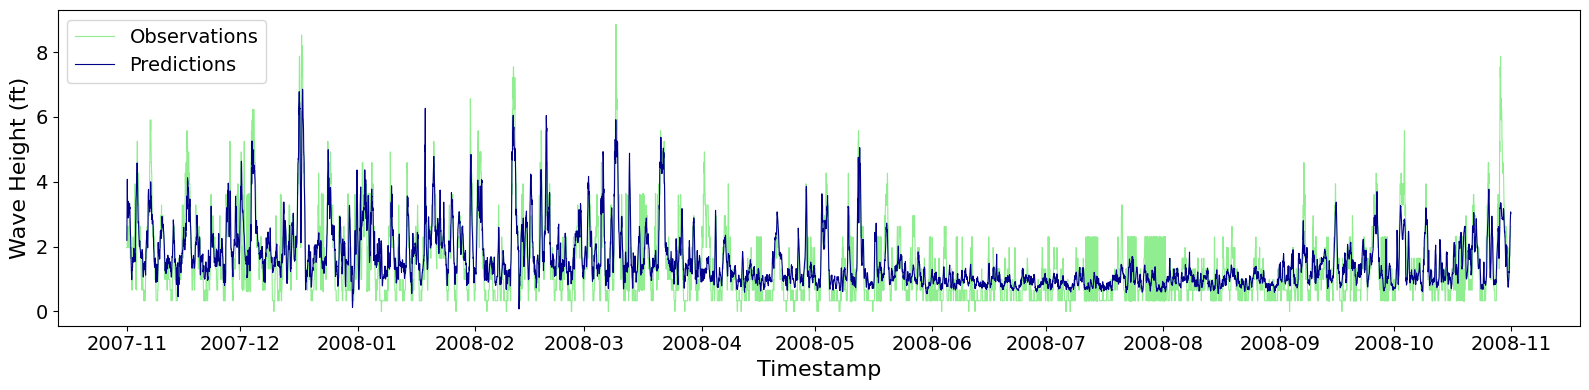

In [6]:
plt.figure(figsize=(16, 4))
plt.plot(df_test.index, df_test['H'], linewidth=0.8, color='lightgreen', label='Observations')
plt.plot(df_test.index, y_pred3_raw, linewidth=0.8, color='darkblue', label='Predictions')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Timestamp', fontsize=16)
plt.ylabel('Wave Height (ft)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()